In [14]:
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt

**The convolution operation**
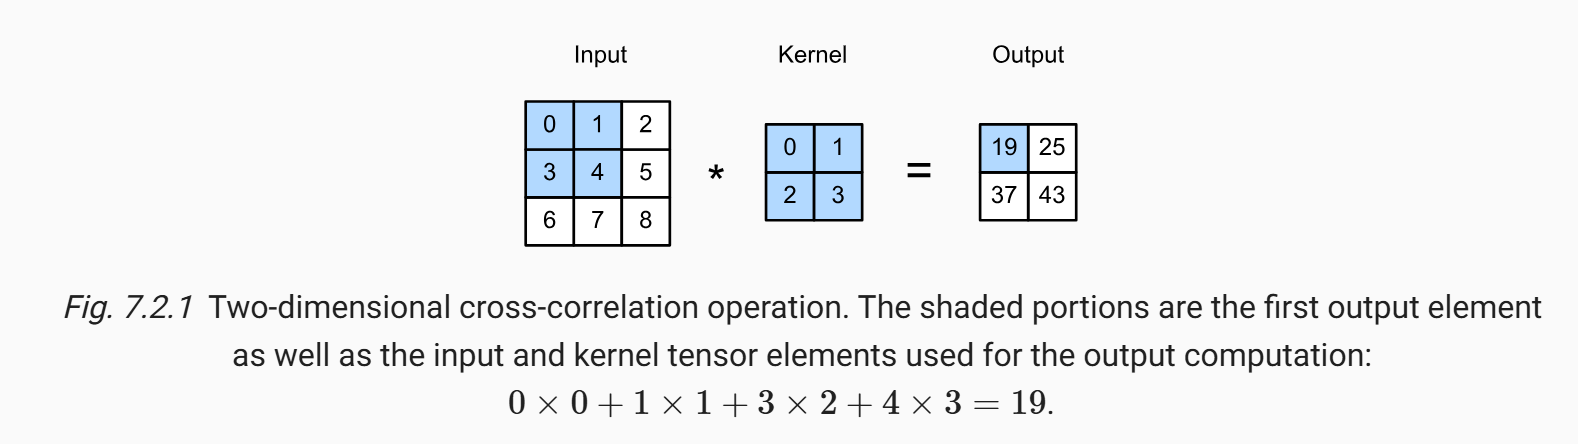

In [6]:
def conv2d(X, K): #@save
    """Compute the convolution for 2D matrices"""
    h, w = K.shape
    Y = torch.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = (X[i:i+h, j:j+w] * K).sum()
    return Y

In [7]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
K = torch.tensor([[0.0,1.0],[2.0,3.0]])
conv2d(X, K)

tensor([[19., 25.],
        [37., 43.]])

In [9]:
class Conv2D(nn.Module):
    """Convolutional Layer"""
    def __init__(self, kernel_size):
        super().__init__()
        self.weight = nn.Parameter(torch.rand(kernel_size))
        self.bias = nn.Parameter(torch.zero(1))

    def forward(self, X):
        return conv2d(X, self.weight) + self.bias

In [ ]:
#Kernels are used to discover image features. First we will hand design an edge detection kernel. Then 
#we will see if the CNN algorithm can discover this hand written feature on its own

tensor([[1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.],
        [1., 1., 0., 0., 0., 0., 1., 1.]])


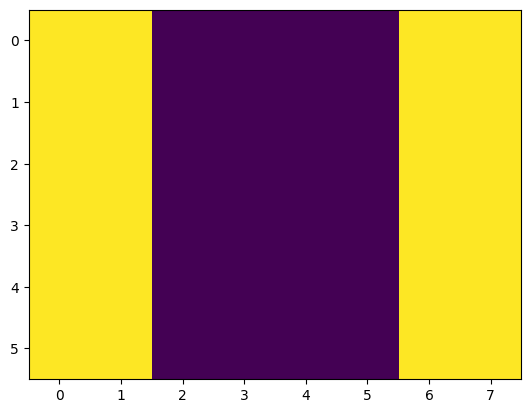

In [15]:
X = torch.ones(6,8)
X[:,2:6] = 0
print(X) # X has white in the centre and black in the middle
plt.imshow(X.numpy())

tensor([[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
        [ 0.,  1.,  0.,  0.,  0., -1.,  0.]])


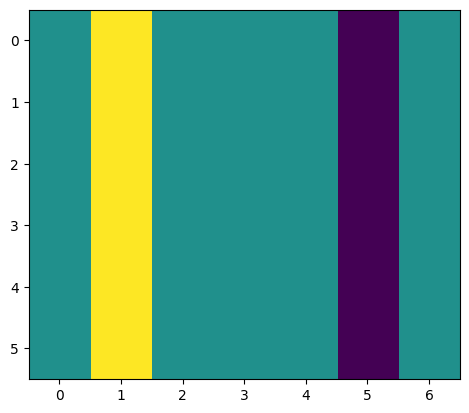

In [17]:
#Edge detection Kernel
K = torch.tensor([[1.0, -1.0]])
Y = conv2d(X, K)
print(Y)
plt.imshow(Y)

In [18]:
#Now we try to learn this kernel using CNN
conv_model = nn.LazyConv2d(1, kernel_size=(1,2), bias=False)

X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2

for i in range(10):
    Y_hat = conv_model(X)
    l = (Y_hat - Y) ** 2
    conv_model.zero_grad()
    l.sum().backward()

    conv_model.weight.data[:] -= lr * conv_model.weight.grad
    if(i+1)%2 == 0:
        print(f"epoch({i}+1), loss {l.sum():.3f}")


epoch(1+1), loss 10.987
epoch(3+1), loss 2.896
epoch(5+1), loss 0.917
epoch(7+1), loss 0.331
epoch(9+1), loss 0.128


In [19]:
#See the kernel learnt
conv_model.weight.data

tensor([[[[ 1.0228, -0.9505]]]])